this is a Julia ipynb and requires a Julia kernel with Julia version >= 1.12

install packages

In [ ]:
using Pkg
Pkg.add(["CairoMakie","PyFormattedStrings","PyCall","JLD2","Printf","SpecialFunctions","MathTeXEngine","LaTeXStrings","EllipticFunctions","Colors"])

In [2]:
using CairoMakie
using PyFormattedStrings
using PyCall
using JLD2
using Printf
using SpecialFunctions
using MathTeXEngine
using LaTeXStrings
using EllipticFunctions

In [49]:
include("../include/gc_utils.jl")

rho_rho_corr_canonical (generic function with 1 method)

data loading

In [42]:
function load_result(key; T, alg=:ce, bc=:pbc, L=20, N=10, folder = "../data/dmrg")
    path = f"{key}_finite_{alg}_T{T:+5.5f}_jvvp_L{L:d}_N{N:d}_J+1.00000_V+0.50000_Vp+0.00000_mu+0.50000_{bc}.jld2"
 
    q = load(joinpath(folder, path), f"{key}")
end
function get_rhorho_ce(; T, bc=:pbc, L=50, N=L÷2) 
    alg = :ce
    (n,err_n) = load_result(:n; T, alg, bc, L, N)
    (nn,err_nn) = load_result(:nn; T, alg, bc, L, N)

    L = length(n)
    N = sum(n) 
    ρ0 = N/L

    rhorho = zeros(L)
    err_rhorho = zeros(L)

    for j = 1:L
        rhorho += [nn[i,1]/ρ0^2 for i = 1:L]  
        err_rhorho += [err_nn[1,i]/ρ0^2 for i = 1:L] 
    end
    
    rhorho / L, err_rhorho / L
end
function avg_rhorho(nn)
    L = size(nn,1)
    @assert size(nn,2) == L
    nn_avg = zeros(eltype(nn), L)
    for r in 0:(L-1)
        s = zero(eltype(nn))
        for i in 1:L
            j = mod1(i + r, L)
            s += nn[i,j]
        end
        nn_avg[r+1] = s / L
    end
    return nn_avg
end
function get_rhorho_gce(; T, bc=:pbc, L=20, N=10, j=:avg)
    alg = :gce
    n = load_result(:n; T, alg, bc, L, N)
    nn = load_result(:nn; T, alg, bc, L, N)

    L = length(n)
    N = sum(n)
    ρ0 = N/L 

    if j == :avg
        return avg_rhorho(nn)/ρ0^2
    else
        return [nn[i,j]/ρ0^2 for i = 1:L]
    end
end

get_rhorho_gce (generic function with 1 method)

load plot style

In [9]:
include("../include/plot_style.jl")

#### Figure: Grand canonical particle number distribution
Distribution $P(N)$ of the particle number in grand-canonical simulations of the $J$-$V$-model with $L=50$, $V/J=0.5$, and $\mu/J=0.5$ at finite temperatures (colors). The curves are peaked at the mean $\langle N\rangle=25$.

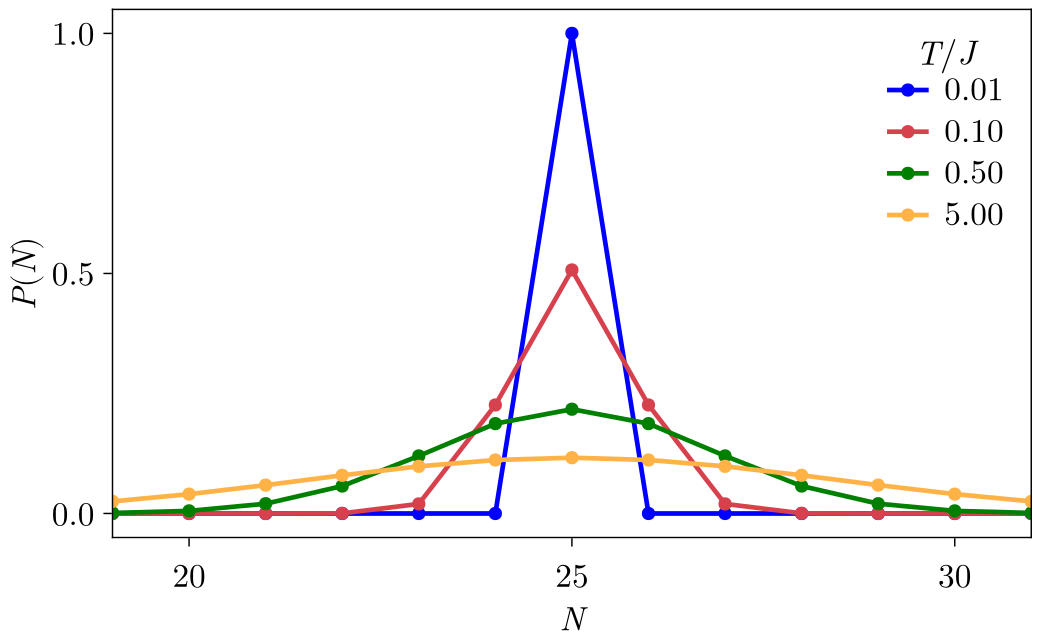

In [28]:
let 
    Ts = [0.01, 0.1, 0.5, 5.0];
    fig = Figure()
    ax = Axis(fig[1,1]; xlabel=L"N", ylabel=L"P(N)")

    colors = get_colors()
    for (i,T) in enumerate(Ts)
        PN = load_result(:PN; T, alg=:gce, L=50, N=10)
        scatterlines!(ax, 0:length(PN)-1, PN; label=latexstring(f"{T:1.2f}"), linestyle=:solid, markersize=6, color=colors[i]) 
    end 

    xlims!(25-6,25+6-0.001)
    axislegend(ax, L"T/J";titlesize=11, titlegap=0)
    save("../figures/JVVpPNofT.pdf", fig)
    fig
end

Below are the plots, the fits for obtaining the parameters used for the theory lines are in the end of the notebook. 

#### Figure: Density-density correlation function
Density-density correlation function as a function of the position $r/L$ for simulations of the $J$-$V$-model with $L=50$, $V/J=0.5$, $\mu/J=0$, and $T/J=0.5$. We show results for both grand-canonical simulations (blue squares) and canonical simulations (red circles) at half-filling $N=25$. Solid lines depict fitted curves to the GCE (blue) and CE (red) theory curves to the data. 

In [58]:
include("../include/gc_utils.jl")

rho_rho_corr_gc (generic function with 1 method)

K0=0.8614293939143047
v0=2.307713313263815


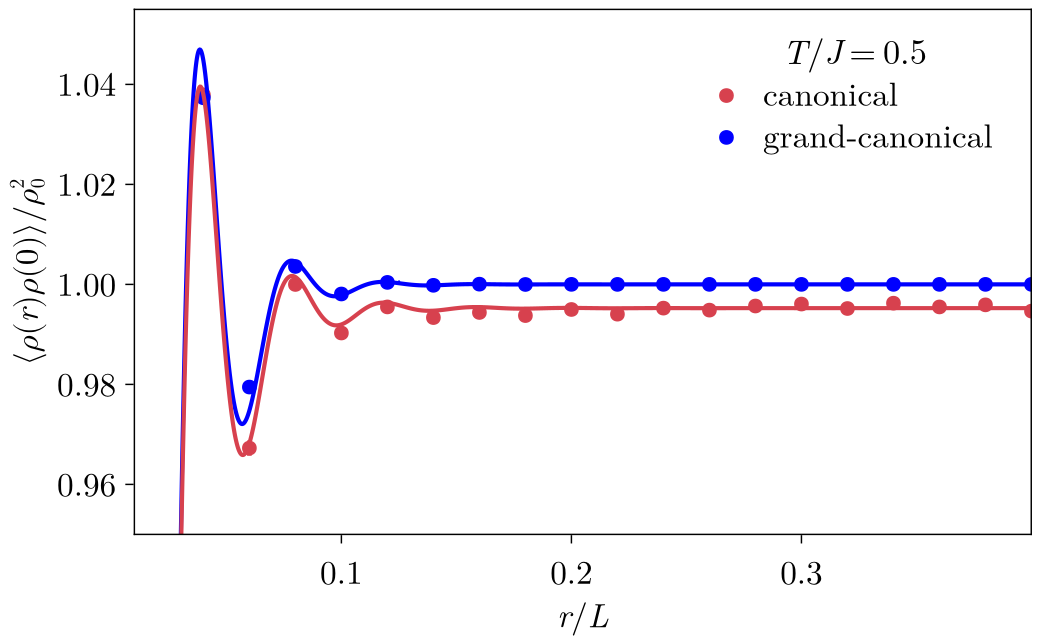

In [67]:
 let
    T = 0.5
    fig = Figure()
    ax = Axis(fig[1,1]; xlabel=L"r/L", ylabel=L"\langle\rho(r)\rho(0)\rangle/\rho_0^2")
    colors = get_colors()

    # load data
    rhorho_gce = get_rhorho_gce(; T, bc=:pbc, L=50)
    rhorho_ce, err_ce = get_rhorho_ce(; T, bc=:pbc, L=50)

    Lsys = length(rhorho_ce)
    rs = collect(0:Lsys-1)
 
    # plot data (with error bars)
    errorbars!(ax, rs ./ Lsys, rhorho_ce, err_ce; color=colors[2])
    scatter!(ax, rs ./ Lsys, rhorho_ce; label=L"canonical $ $", color=colors[2], strokecolor=colors[2], markersize=6)
   
    
    # theory curve
    ρ0 =  1/2 
    t  = 1.0
    V  = 0.5
    μ0 = 0.0

    out = luttinger_tV(; t, V, a=1.0)
    K0 = out.K
    v0 = out.v
    A_ce = 2.66e-6
    A_gce = 3.01e-6
    println("K0=",K0)
    println("v0=",v0)
 
    xs = 0.0:0.01:Lsys
    β = 1/T 

    yfit_ce = [real(rho_rho_corr_canonical(x; ρ0, L=Lsys, K=K0, β, v_s=v0, A=A_ce, a0=0.0 ))/(ρ0^2) for x in xs]

 
    scatter!(ax, rs ./ Lsys, rhorho_gce; label=L"grand-canonical $ $", color=colors[1], strokecolor=colors[1], markersize=6)
   

    yfit_gce = [real(rho_rho_corr_gc(x; ρ0, L=Lsys, K=K0, β, μ=0.0, v_s=v0, A=A_gce , a0=0.0 ))/(ρ0^2) for x in xs]

    lines!(ax, xs ./ Lsys, yfit_gce; color=colors[1] )
    lines!(ax, xs ./ Lsys, yfit_ce;  color=colors[2] )
 

    axislegend(ax, L"T/J = 0.5"; titlesize=11, titlegap=2, position=:rt)
    xlims!(ax, 0.01, 0.3999)
    ylims!(ax, 0.95, 1.055)

    save("../figures/JVVp_rhorho_fits_gce_ce.pdf", fig)
    fig
end

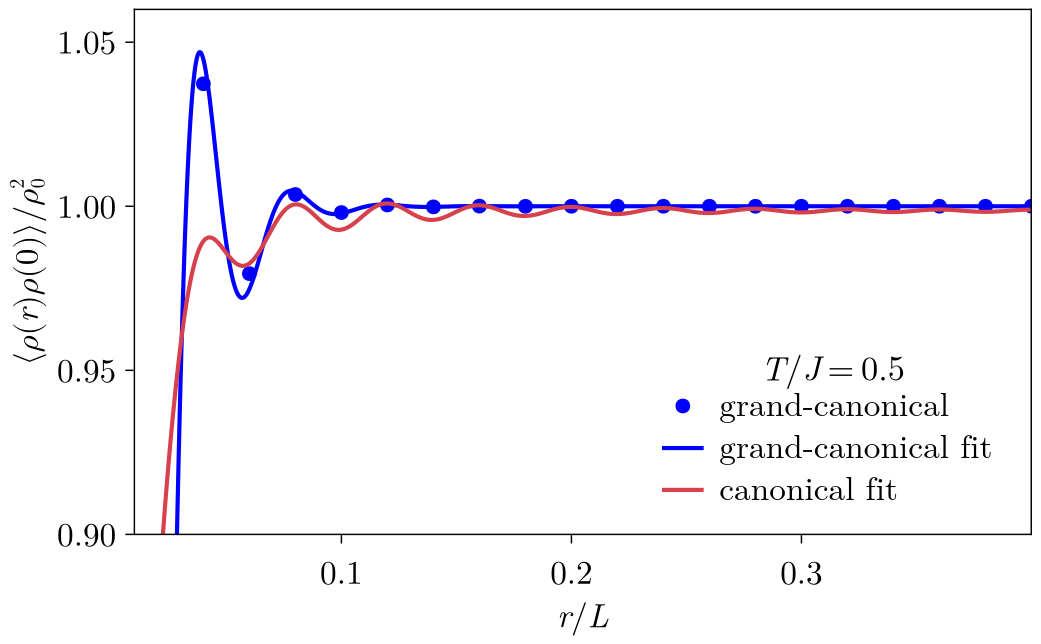

In [73]:
 let
    T = 0.5
    fig = Figure()
    ax = Axis(fig[1,1]; xlabel=L"r/L", ylabel=L"\langle\rho(r)\rho(0)\rangle/\rho_0^2")
    colors = get_colors()

    # load data
    rhorho_gce = get_rhorho_gce(; T,  bc=:pbc, L=50)
    rhorho_ce, err_ce = get_rhorho_ce(; T, bc=:pbc, L=50)

    Lsys = length(rhorho_ce)
    rs = collect(0:Lsys-1)
 
    # plot data (with error bars)
    scatter!(ax, rs ./ Lsys, rhorho_gce; label=L"grand-canonical $ $", color=colors[1], strokecolor=colors[1], markersize=6)
    
    # theory curve
    ρ0 =  1/2 
    t  = 1.0
    V  = 0.5
    μ0 = 0.0

    out = luttinger_tV(; t=t, V=V, a=1.0)
    K0 = out.K
    v0 = out.v 
    A_gce = 3.01e-6
    
    A_ce = 0.00026855954007014337; K_ce = 0.5004446974934126; v_ce = 4.6881080213879125; a0_ce = 9.375601527298002 
 
    xs = 0.0:0.01:Lsys
    β = 1/T 

    yfit_ce = [real(rho_rho_corr_canonical(x;
        ρ0=ρ0, L=Lsys, K=K_ce, β=β, v_s=v_ce, A=A_ce, a0=a0_ce
    ))/(ρ0^2) for x in xs]

    yfit_gce = [real(rho_rho_corr_gc(x;
        ρ0=ρ0, L=Lsys, K=K0, β=β, μ=0.0, v_s=v0, A=A_gce , a0=0.0
    ))/(ρ0^2) for x in xs]

    lines!(ax, xs ./ Lsys, yfit_gce; color=colors[1], label=L"grand-canonical fit $ $")
    lines!(ax, xs ./ Lsys, yfit_ce;  color=colors[2], label=L"canonical fit $ $")

    axislegend(ax, L"T/J = 0.5"; titlesize=11, titlegap=0, position=:rb)
    xlims!(ax, 0.01, 0.3999)
    ylims!(ax, 0.9, 1.06)

    save("../figures/JVVp_rhorho_fitgcevsce_to_gce.pdf", fig)
    fig
end

## Fits for plots above

In [76]:
using EllipticFunctions: etaDedekind  
using PyCall  
using Statistics
using Printf
using SpecialFunctions 

const np = pyimport("numpy")

py"""
import numpy as np
from scipy.optimize import curve_fit

def _generic_fitter(model_func, x, y, yerr, p0, bounds):
    popt, pcov = curve_fit(
        model_func,
        x, y,
        p0=p0,
        sigma=yerr,
        absolute_sigma=True,
        method="trf",      
        bounds=bounds,
        maxfev=100000
    )
    perr = np.sqrt(np.diag(pcov))
    return popt, perr, pcov
"""

py"""
import numpy as np
from scipy.optimize import curve_fit

def _generic_fitter_noerror(model_func, x, y, p0, bounds):
    popt, pcov = curve_fit(
        model_func,
        x, y,
        p0=p0,
        sigma=None,
        absolute_sigma=False,
        method="trf",   
        bounds=bounds,
        maxfev=100000
    )
    perr = np.sqrt(np.diag(pcov))
    return popt, perr, pcov
"""

function curve_fit_bounds(model::PyObject, x, y, yerr; p0, bounds)
    yerr === nothing && return py"_generic_fitter_noerror"(model, x, y, p0, bounds)
    return py"_generic_fitter"(model, x, y, yerr, p0, bounds)
end

function fit_rhorho_ce_bounded(rs, y, yerr;
    ρ0, L, T,
    ħ=1.0, t=1.0, V=0.5,
    rmin::Int=2, rmax::Int=Int(floor(L/2)),
    A0=1e-4, a0_init=0.5,
    #μ=0.0,
    vmin::Float64=1e-4,
    vmax=Inf
)
    β = 1 / T
    out = luttinger_tV(; t=t, V=V, a=1.0)
    K0 = out.K
    v0 = out.v

    mask = (rs .>= rmin) .& (rs .<= rmax)
    x  = Float64.(rs[mask])
    yy = Float64.(y[mask])
    ee = Float64.(yerr[mask])

    model = PyObject(function(xarr, A, K, v, a0)
        xs = Array(xarr)
        vals = Vector{Float64}(undef, length(xs))
        @inbounds for i in eachindex(xs)
            vals[i] = real(rho_rho_corr_canonical(xs[i]; ρ0=ρ0, L=L, K=K, β=β, v_s=v, A=A, a0=a0 )) / (ρ0^2)
        end
        return vals
    end)
 
    p0 = [A0, K0, v0, a0_init]
     
    # A is unbounded, K > 0.1, v_s > vmin, a0 > 0.001
    bounds = ([-Inf, 0.1, vmin, 0.0], [Inf, 10.0, vmax, 10.0])

    popt, perr, pcov = curve_fit_bounds(model, np.array(x), np.array(yy), np.array(ee); 
                                        p0=p0, bounds=bounds)

    Â = popt[1]
    K̂ = popt[2]
    v̂ = popt[3]
    a0_hat = popt[4]

    σA = perr[1]
    σK = perr[2]
    σv = perr[3]
    σa0 = perr[4]

    return (params=(A=Â, K=K̂, v_s=v̂, a0=a0_hat),
            errors=(A=σA, K=σK, v_s=σv, a0=σa0),
            cov=pcov)
end

function fit_rhorho_gce_bounded(rs, y, yerr;
    ρ0, L, T, μ, t=1.0, V=0.5,
    rmin::Int=2, rmax::Int=Int(floor(L/2)),
    A0=1e-4, a0_init=0.5,
    umin::Float64=1e-5  
)
    β = 1 / T
    out = luttinger_tV(; t=t, V=V, a=1.0)
    K0 = out.K
    v0 = out.v

    u0 = v0 - μ
    u0 = u0 <= umin ? umin + 0.1 : u0

    mask = (rs .>= rmin) .& (rs .<= rmax)
    x  = Float64.(rs[mask])
    yy = Float64.(y[mask])
    ee = yerr === nothing ? nothing : Float64.(yerr[mask])

    model = PyObject(function(xarr, A, K, u, a0)
        v = (μ + u) 
        xs = Array(xarr)
        vals = Vector{Float64}(undef, length(xs))
        @inbounds for i in eachindex(xs)
            vals[i] = real(rho_rho_corr_gc(xs[i]; ρ0=ρ0, L=L, K=K, β=β, μ=μ, v_s=v, A=A, a0=a0 )) / (ρ0^2)
        end
        return vals
    end)
 
    p0 = [A0, K0, u0, a0_init]
    
    bounds = ([-Inf, 0.1, umin, 0.0], [Inf, 10.0, Inf, 10.0])

    popt, perr, pcov = curve_fit_bounds(model, np.array(x), np.array(yy), np.array(ee); 
                                        p0=p0, bounds=bounds)

    Â = popt[1]
    K̂ = popt[2]
    û = popt[3]
    v̂ = (μ + û) 
    a0_hat = popt[4]

    σA = perr[1]
    σK = perr[2]
    σv = perr[3] 
    σa0 = perr[4]

    return (params=(A=Â, K=K̂, v_s=v̂, μ=μ, a0=a0_hat),
            errors=(A=σA, K=σK, v_s=σv, μ=0.0, a0=σa0),
            cov=pcov)
end

fit_rhorho_gce_bounded (generic function with 1 method)

### Fit CE data to CE theory

In [77]:
let 
    T = 0.5
    V = 0.5
    t = 1.0
    L = 50 

    rhorho_ce, err_ce = get_rhorho_ce(; T=T,bc=:pbc, L)

    Lsys = length(rhorho_ce)
    @assert Lsys == L

    rs = collect(0:Lsys-1)

    start = 3
    last = length(rs)
 
    fit_ce = fit_rhorho_ce_bounded(rs[start:last], rhorho_ce[start:last], err_ce[start:last];
        ρ0=1/2, L=Lsys, T, ħ=1.0, t, V, 
        rmin=2, rmax=Int(floor(Lsys/2)), A0=1.0e-5, a0_init=0.0, vmin=1.0, vmax=3.0
    )
end

(params = (A = 2.6563180085205343e-6, K = 0.8614293933561342, v_s = 2.3077133134255843, a0 = 1.0e-10), errors = (A = 5.519632642571291e-7, K = 0.04753846559004172, v_s = 0.11997563494870764, a0 = 0.0), cov = [3.0466344508938535e-13 -1.3442774056578822e-8 -4.544839980957276e-9 0.0; -1.3442774056578822e-8 0.002259905710655581 0.005086529575600309 0.0; -4.5448399809572756e-9 0.005086529575600308 0.014394152981345559 0.0; 0.0 0.0 0.0 0.0])

### Fit GCE data to GCE theory

In [81]:
let 
    T = 0.5
    V = 0.5
    t = 1.0
    L = 50 

    rhorho_gce = get_rhorho_gce(; T, bc=:pbc, L=50)

    Lsys = length(rhorho_gce)
    @assert Lsys == L

    rs = collect(0:Lsys-1)

    start = 10
    last = length(rs)
  

    fit_gce = fit_rhorho_gce_bounded(rs[start:last], rhorho_gce[start:last], nothing;
        ρ0=1/2, L=Lsys, T, t, V, μ=0.0,
        rmin=2, rmax=Int(floor(Lsys/2)), A0=1.0e-5, a0_init=0.0, umin=1e-5
    )
end

(params = (A = 3.0088842390069976e-6, K = 0.8614293939002791, v_s = 2.3077133131897334, μ = 0.0, a0 = 1.0e-10), errors = (A = 0.9767556667202645, K = 112209.51961862142, v_s = 464348.8530478874, μ = 0.0, a0 = 0.0), cov = [0.9540516324701485 5809.404108489068 -443667.43218777946 0.0; 5809.4041084890705 1.2590976293041784e10 -8.685501581385822e9 0.0; -443667.43218777946 -8.68550158138582e9 2.156198573268885e11 0.0; 0.0 0.0 0.0 0.0])

### Fit CE theory to GCE data

In [80]:
let 
    T = 0.5
    V = 0.5
    t = 1.0
    L = 50 

    rhorho_gce = get_rhorho_gce(; T, bc=:pbc, L=50)
    rhorho_gce_err = fill(0.001, length(rhorho_gce)) # Dummy errors for fitting

    Lsys = length(rhorho_gce)
    @assert Lsys == L

    rs = collect(0:Lsys-1)

    start = 4
    last = length(rs)
 
    fit_ce = fit_rhorho_ce_bounded(rs[start:last], rhorho_gce[start:last], rhorho_gce_err[start:last];
        ρ0=1/2, L=Lsys, T, ħ=1.0, t, V, 
        rmin=2, rmax=Int(floor(Lsys/2)), A0=3.0e-6, a0_init=0.0, vmin=1.0, vmax=5.0
    )
end

(params = (A = 0.00026855954007014337, K = 0.5004446974934126, v_s = 4.6881080213879125, a0 = 9.375601527298002), errors = (A = 0.032094572828064855, K = 0.13094623847063194, v_s = 1.2514919105370508, a0 = 949.3001602349997), cov = [0.0010300616050159589 -0.00407147832445742 -0.03500533405407712 30.467355591385193; -0.004071478324457419 0.017146917369607606 0.14285168624967454 -120.39857676358456; -0.03500533405407711 0.1428516862496745 1.5662320021396776 -1035.6506262015203; 30.467355591385193 -120.39857676358456 -1035.6506262015205 901170.7942221961])